# 07 — MMM: ROI Analysis & Budget Optimization

## Objective
Using the causal model fitted in **Notebook 06**, this notebook:
1. **Computes ROI per media channel** — which channels generate the most revenue per dollar spent?
2. **Decomposes revenue** — what portion is driven by media vs baseline vs weather vs seasonality?
3. **Optimizes budget allocation** — how should the budget be reallocated to maximize revenue?
4. **Runs scenario analysis** — what-if analysis for budget changes

## Relationship to Notebook 06
- **NB06 (Causal Inference)**: Fits Ridge regression models, validates with bootstrap/LOOCV, outputs coefficients and effectiveness metrics
- **NB07 (This notebook)**: Loads NB06 outputs, interprets results as ROI, runs optimization

**No model re-fitting here** — we use the validated model from NB06.

## Inputs from Notebook 06
| File | Contents |
|------|----------|
| `media_effectiveness_results.csv` | Marginal effects, ROAS, contribution per channel per product |
| `saturation_curves.csv` | Spend vs incremental revenue curves |
| `causal_model_params.json` | Decay rates, saturation params, Ridge alphas, R², feature names |
| `robustness_summary.csv` | Stability checks for coefficient estimates |

## Key Deliverables
1. **ROI Table** — revenue generated per $1 spent, per channel
2. **Revenue Decomposition** — waterfall chart showing contribution by driver
3. **Marginal ROI Curves** — diminishing returns visualization
4. **Budget Optimization** — recommended reallocation to maximize revenue
5. **Scenario Analysis** — what-if analysis for budget changes

---

## Section 0 — Setup & Load NB06 Outputs

In [1]:
# ---------- Imports ----------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
import warnings
from datetime import datetime

from scipy.optimize import minimize, LinearConstraint

warnings.filterwarnings('ignore')

# ---------- Plot settings ----------
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (14, 7),
    'font.size': 11,
    'figure.dpi': 120,
    'savefig.bbox': 'tight',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
sns.set_palette('husl')

# ---------- Paths ----------
project_root = Path().cwd().parent if Path().cwd().name == 'notebooks' else Path().cwd()
processed_path = project_root / 'data' / 'processed'
figures_path = project_root / 'reports' / 'figures'
reports_path = project_root / 'reports'

figures_path.mkdir(parents=True, exist_ok=True)
reports_path.mkdir(parents=True, exist_ok=True)

print(f'Project root : {project_root}')
print(f'Processed    : {processed_path}')
print(f'Figures      : {figures_path}')

Project root : /Users/raoul/Dev/busa693-clubpiscine
Processed    : /Users/raoul/Dev/busa693-clubpiscine/data/processed
Figures      : /Users/raoul/Dev/busa693-clubpiscine/reports/figures


In [2]:
# ---------- Load NB06 outputs ----------

# 1. Effectiveness results (main deliverable from NB06)
eff_df = pd.read_csv(processed_path / 'media_effectiveness_results.csv')
print(f'✓ Loaded media_effectiveness_results.csv: {eff_df.shape}')

# 2. Saturation curves
sat_curves_df = pd.read_csv(processed_path / 'saturation_curves.csv')
print(f'✓ Loaded saturation_curves.csv: {sat_curves_df.shape}')

# 3. Model parameters
with open(processed_path / 'causal_model_params.json') as f:
    model_params = json.load(f)
print(f'✓ Loaded causal_model_params.json')

# 4. Robustness summary
try:
    robust_df = pd.read_csv(processed_path / 'robustness_summary.csv')
    print(f'✓ Loaded robustness_summary.csv: {robust_df.shape}')
except FileNotFoundError:
    robust_df = None
    print('⚠ robustness_summary.csv not found (optional)')

# 5. Transformation parameters (from NB05)
with open(processed_path / 'optimal_transformation_params.json') as f:
    transform_params = json.load(f)
print(f'✓ Loaded optimal_transformation_params.json')

✓ Loaded media_effectiveness_results.csv: (49, 10)
✓ Loaded saturation_curves.csv: (70, 4)
✓ Loaded causal_model_params.json
✓ Loaded robustness_summary.csv: (7, 5)
✓ Loaded optimal_transformation_params.json


In [3]:
# ---------- Load raw data for context ----------
df = pd.read_pickle(processed_path / 'sales_spend_weather.pkl')
df = df.sort_values('date').reset_index(drop=True)

print(f'\nDataset: {df.shape[0]} months, {df.shape[1]} columns')
print(f'Date range: {df["date"].min().date()} — {df["date"].max().date()}')
print(f'Fiscal years: {sorted(df["year"].unique())}')


Dataset: 36 months, 43 columns
Date range: 2022-11-01 — 2025-10-01
Fiscal years: [np.int64(2023), np.int64(2024), np.int64(2025)]


In [4]:
# ---------- Extract key parameters from NB06 ----------

# Media channels
MEDIA_CHANNELS = ['media_' + ch for ch in model_params['media_channels']]

# Spend column mapping
SPEND_TO_MEDIA = {
    'media_television':          'spend_television',
    'media_radio':               'spend_radio',
    'media_panneaux':            'spend_panneaux',
    'media_social_media':        'spend_social_media',
    'media_preroll':             'spend_preroll',
    'media_banniere_web':        'spend_banniere_web',
    'media_circulaire_digitale': 'spend_circulaire_digitale',
}

# Channel display names
CHANNEL_LABELS = {
    'media_television':          'Television',
    'media_radio':               'Radio',
    'media_panneaux':            'Panneaux (Outdoor)',
    'media_social_media':        'Social Media',
    'media_preroll':             'Preroll (Video)',
    'media_banniere_web':        'Web Banners',
    'media_circulaire_digitale': 'Digital Flyers',
}

# Decay rates and saturation params
DECAY_RATES = {'media_' + k: v for k, v in model_params['decay_rates'].items()}
SATURATION_PARAMS = {'media_' + k: v for k, v in model_params['saturation_params'].items()}

# Model performance
print('Model Performance (from NB06):')
print('-' * 50)
for product, r2 in model_params.get('ridge_r2', {}).items():
    r2_cv = model_params.get('ridge_r2_cv', {}).get(product, 'N/A')
    print(f'  {product:30s}  R²={r2:.3f}  LOOCV R²={r2_cv:.3f}')

Model Performance (from NB06):
--------------------------------------------------
  Total Revenue                   R²=0.966  LOOCV R²=0.912
  Above-Ground Pools (HT)         R²=0.854  LOOCV R²=0.733
  In-Ground Pools (CR)            R²=0.668  LOOCV R²=0.531
  Spas (SP)                       R²=0.929  LOOCV R²=0.855
  Furniture & Gazebo (ME&GA)      R²=0.966  LOOCV R²=0.915
  Fitness (FI)                    R²=0.570  LOOCV R²=0.415
  BBQ (BQ)                        R²=0.958  LOOCV R²=0.887


In [5]:
# ---------- Compute totals from raw data ----------

# Total revenue
total_revenue = df['total_all_revenue'].sum()
avg_monthly_revenue = df['total_all_revenue'].mean()

# Total spend
spend_cols = [c for c in df.columns if c.startswith('spend_') and c != 'spend_total']
total_spend = df[spend_cols].sum().sum()
avg_monthly_spend = total_spend / len(df)

print('3-Year Summary:')
print(f'  Total Revenue:       ${total_revenue:>15,.0f}')
print(f'  Avg Monthly Revenue: ${avg_monthly_revenue:>15,.0f}')
print(f'  Total Media Spend:   ${total_spend:>15,.0f}')
print(f'  Avg Monthly Spend:   ${avg_monthly_spend:>15,.0f}')
print(f'  Overall ROAS:        {total_revenue / total_spend:>15.2f}')

3-Year Summary:
  Total Revenue:       $    512,411,602
  Avg Monthly Revenue: $     14,233,656
  Total Media Spend:   $     10,257,505
  Avg Monthly Spend:   $        284,931
  Overall ROAS:                  49.95


---
## Section 1 — ROI Analysis (from NB06 Effectiveness Results)

In [6]:
# ===================================================================
# 1-A  EXTRACT ROI METRICS FROM EFFECTIVENESS TABLE
# ===================================================================

# Focus on Total Revenue
eff_total = eff_df[eff_df['product'] == 'Total Revenue'].copy()

# ROAS from NB06 = marginal revenue per $1 spent
# marginal_per_1000 = incremental revenue per $1,000 spent
# So: ROI = marginal_per_1000 / 1000 = roas

roi_data = []
for _, row in eff_total.iterrows():
    ch = 'media_' + row['channel']
    label = CHANNEL_LABELS.get(ch, row['channel'])
    
    roi_data.append({
        'channel': ch,
        'label': label,
        'total_spend': row['total_spend'],
        'marginal_per_1000': row['marginal_per_1000'],
        'marginal_ci_lo': row['marginal_ci_lo'],
        'marginal_ci_hi': row['marginal_ci_hi'],
        'roas': row['roas'],  # This is ROI (revenue per $1 spent)
        'total_contribution': row['total_contribution'],
        'saturation_pct': row['saturation_pct'],
        'ridge_coef': row['ridge_coef_std'],
    })

roi_df = pd.DataFrame(roi_data)

# Compute shares
roi_df['spend_share'] = roi_df['total_spend'] / roi_df['total_spend'].sum()
positive_contrib = roi_df['total_contribution'].clip(lower=0).sum()
roi_df['contrib_share'] = roi_df['total_contribution'].clip(lower=0) / positive_contrib

# Efficiency index
roi_df['efficiency_index'] = roi_df['contrib_share'] / roi_df['spend_share'].replace(0, np.nan)

# Sort by ROAS
roi_df = roi_df.sort_values('roas', ascending=False).reset_index(drop=True)

print('=' * 100)
print('ROI ANALYSIS BY CHANNEL (Total Revenue)')
print('=' * 100)
print(f'{"Channel":25s} {"Spend":>12s} {"Spend%":>8s} {"ROAS":>8s} {"$/1K":>10s} {"90% CI":>20s} {"Contrib":>12s}')
print('-' * 100)
for _, row in roi_df.iterrows():
    ci_str = f"[{row['marginal_ci_lo']:>6.0f}, {row['marginal_ci_hi']:>6.0f}]"
    roas_str = f"{row['roas']:.2f}" if row['roas'] > 0 else 'N/A'
    print(f"{row['label']:25s} ${row['total_spend']:>10,.0f} {row['spend_share']*100:>7.1f}% {roas_str:>8s} ${row['marginal_per_1000']:>8,.0f} {ci_str:>20s} ${row['total_contribution']:>10,.0f}")
print('-' * 100)
print(f"{'TOTAL':25s} ${roi_df['total_spend'].sum():>10,.0f}")

ROI ANALYSIS BY CHANNEL (Total Revenue)
Channel                          Spend   Spend%     ROAS       $/1K               90% CI      Contrib
----------------------------------------------------------------------------------------------------
Preroll (Video)           $   812,648     7.9%   321.46 $ 321,458     [168100, 405599] $         0
Social Media              $   827,421     8.1%   145.40 $ 145,397     [-73200, 269956] $        -0
Panneaux (Outdoor)        $   292,495     2.9%    73.51 $  73,513     [-59693, 198123] $        -0
Radio                     $ 2,167,277    21.1%    27.47 $  27,473     [ -2866,  49715] $        -0
Web Banners               $ 1,762,168    17.2%     8.44 $   8,437     [-45966,  79697] $        -0
Television                $ 3,948,951    38.5%      N/A $  -5,608     [-18492,  21066] $         0
Digital Flyers            $   446,546     4.4%      N/A $ -69,861    [-178542, 114839] $        -0
----------------------------------------------------------------

In [7]:
# ===================================================================
# 1-B  ROI INTERPRETATION
# ===================================================================

print('\nROI INTERPRETATION:')
print('=' * 70)
print('\nROAS (Return on Ad Spend) = Marginal revenue per $1 spent')
print('  - ROAS > 1: Channel generates more revenue than it costs')
print('  - ROAS < 1: Channel costs more than incremental revenue')
print('  - ROAS < 0: Channel has negative association (confounding likely)')
print()

# Categorize channels
high_roi = roi_df[roi_df['roas'] > 1]['label'].tolist()
moderate_roi = roi_df[(roi_df['roas'] > 0) & (roi_df['roas'] <= 1)]['label'].tolist()
negative_roi = roi_df[roi_df['roas'] <= 0]['label'].tolist()

print('Channel Categories:')
print(f'  ✓ High ROI (ROAS > 1):       {high_roi if high_roi else "None"}')
print(f'  ~ Moderate ROI (0 < ROAS ≤ 1): {moderate_roi if moderate_roi else "None"}')
print(f'  ✗ Negative/Zero ROI:         {negative_roi if negative_roi else "None"}')

# Check statistical significance (CI excludes zero)
print('\nStatistical Significance (90% CI excludes zero):')
for _, row in roi_df.iterrows():
    sig = 'Yes' if (row['marginal_ci_lo'] > 0 or row['marginal_ci_hi'] < 0) else 'No'
    print(f"  {row['label']:25s}  {sig}")


ROI INTERPRETATION:

ROAS (Return on Ad Spend) = Marginal revenue per $1 spent
  - ROAS > 1: Channel generates more revenue than it costs
  - ROAS < 1: Channel costs more than incremental revenue
  - ROAS < 0: Channel has negative association (confounding likely)

Channel Categories:
  ✓ High ROI (ROAS > 1):       ['Preroll (Video)', 'Social Media', 'Panneaux (Outdoor)', 'Radio', 'Web Banners']
  ~ Moderate ROI (0 < ROAS ≤ 1): None
  ✗ Negative/Zero ROI:         ['Television', 'Digital Flyers']

Statistical Significance (90% CI excludes zero):
  Preroll (Video)            Yes
  Social Media               No
  Panneaux (Outdoor)         No
  Radio                      No
  Web Banners                No
  Television                 No
  Digital Flyers             No


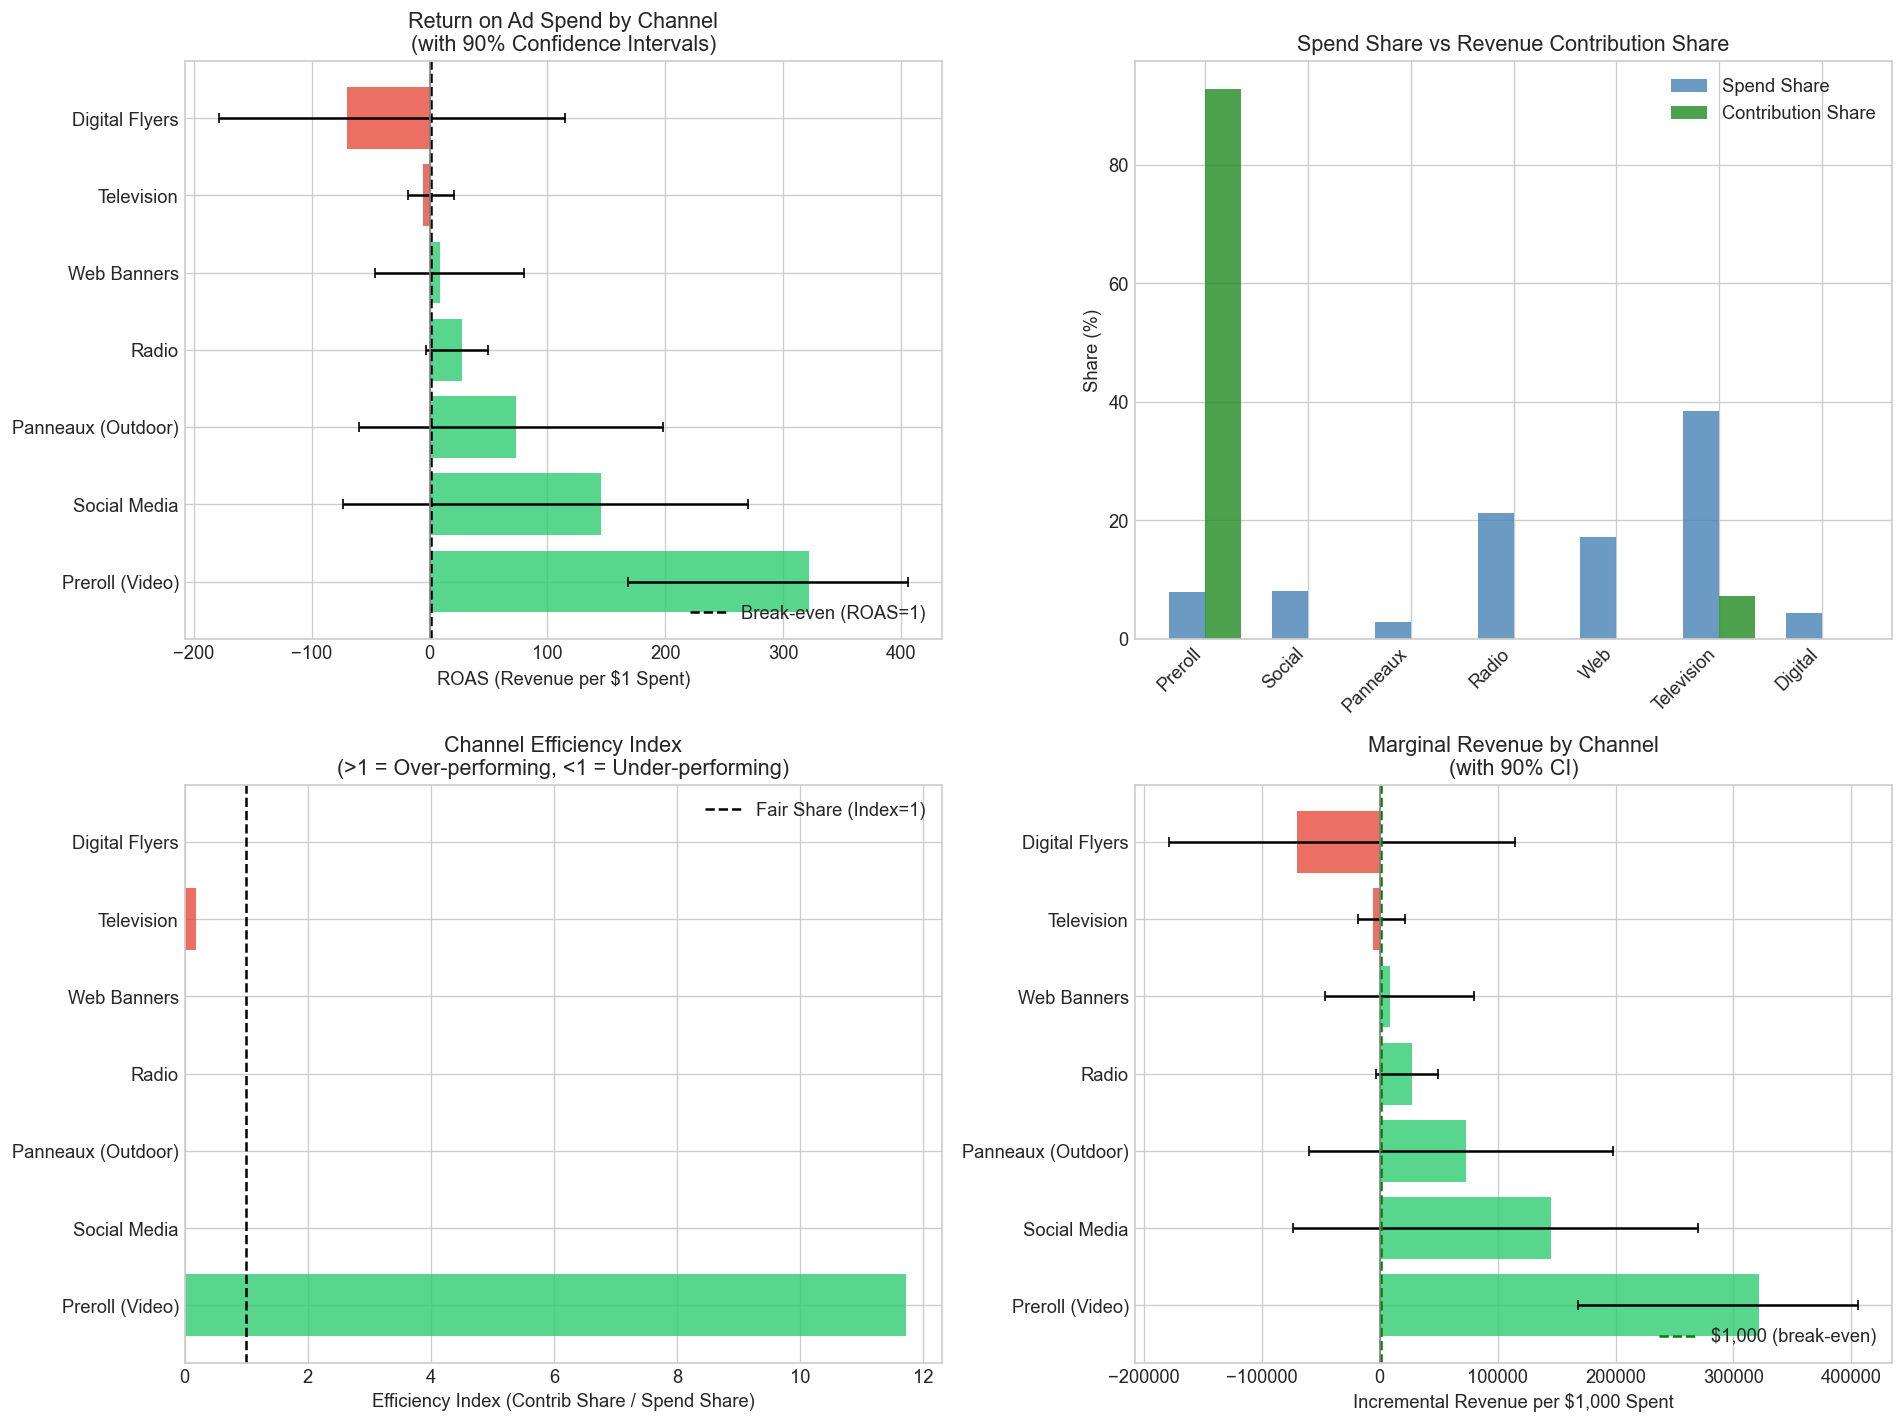

In [8]:
# ===================================================================
# 1-C  ROI VISUALIZATION
# ===================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. ROAS Bar Chart with CI
ax = axes[0, 0]
y_pos = np.arange(len(roi_df))
colors = ['#2ecc71' if r > 1 else '#f39c12' if r > 0 else '#e74c3c' for r in roi_df['roas']]
bars = ax.barh(y_pos, roi_df['roas'], color=colors, alpha=0.8)

# Add error bars from marginal CI (scaled to ROAS units)
ci_lo_roas = roi_df['marginal_ci_lo'] / 1000
ci_hi_roas = roi_df['marginal_ci_hi'] / 1000
xerr = [roi_df['roas'] - ci_lo_roas, ci_hi_roas - roi_df['roas']]
ax.errorbar(roi_df['roas'], y_pos, xerr=xerr, fmt='none', ecolor='black', capsize=3)

ax.axvline(1, color='black', linestyle='--', linewidth=1.5, label='Break-even (ROAS=1)')
ax.axvline(0, color='gray', linestyle='-', linewidth=1)
ax.set_yticks(y_pos)
ax.set_yticklabels(roi_df['label'])
ax.set_xlabel('ROAS (Revenue per $1 Spent)')
ax.set_title('Return on Ad Spend by Channel\n(with 90% Confidence Intervals)')
ax.legend(loc='lower right')

# 2. Spend Share vs Contribution Share
ax = axes[0, 1]
x = np.arange(len(roi_df))
width = 0.35
ax.bar(x - width/2, roi_df['spend_share'] * 100, width, label='Spend Share', color='steelblue', alpha=0.8)
ax.bar(x + width/2, roi_df['contrib_share'] * 100, width, label='Contribution Share', color='forestgreen', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels([l.split()[0] for l in roi_df['label']], rotation=45, ha='right')
ax.set_ylabel('Share (%)')
ax.set_title('Spend Share vs Revenue Contribution Share')
ax.legend()

# 3. Efficiency Index
ax = axes[1, 0]
colors = ['#2ecc71' if e > 1 else '#e74c3c' for e in roi_df['efficiency_index'].fillna(0)]
bars = ax.barh(roi_df['label'], roi_df['efficiency_index'].fillna(0), color=colors, alpha=0.8)
ax.axvline(1, color='black', linestyle='--', linewidth=1.5, label='Fair Share (Index=1)')
ax.set_xlabel('Efficiency Index (Contrib Share / Spend Share)')
ax.set_title('Channel Efficiency Index\n(>1 = Over-performing, <1 = Under-performing)')
ax.legend()

# 4. Marginal Revenue per $1,000
ax = axes[1, 1]
colors = ['#2ecc71' if m > 1000 else '#f39c12' if m > 0 else '#e74c3c' for m in roi_df['marginal_per_1000']]
bars = ax.barh(roi_df['label'], roi_df['marginal_per_1000'], color=colors, alpha=0.8)

# Add CI whiskers
ax.errorbar(roi_df['marginal_per_1000'], np.arange(len(roi_df)),
            xerr=[roi_df['marginal_per_1000'] - roi_df['marginal_ci_lo'],
                  roi_df['marginal_ci_hi'] - roi_df['marginal_per_1000']],
            fmt='none', ecolor='black', capsize=3)
ax.axvline(1000, color='green', linestyle='--', linewidth=1.5, label='$1,000 (break-even)')
ax.axvline(0, color='gray', linestyle='-', linewidth=1)
ax.set_xlabel('Incremental Revenue per $1,000 Spent')
ax.set_title('Marginal Revenue by Channel\n(with 90% CI)')
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig(figures_path / 'mmm_roi_analysis.png', dpi=150)
plt.show()

---
## Section 2 — Revenue Decomposition

In [9]:
# ===================================================================
# 2-A  COMPUTE REVENUE DECOMPOSITION FROM NB06 CONTRIBUTIONS
# ===================================================================

# Total contribution from media channels (from effectiveness table)
media_contribution = eff_total['total_contribution'].sum()

# The remaining revenue is attributed to:
# - Baseline (intercept)
# - Seasonality
# - Weather
#
# Since NB06 decomposes using standardized coefficients × standardized features,
# the total predicted revenue = intercept × N + sum of contributions
#
# We estimate non-media contribution as: Total Revenue - Media Contribution
# Then split this into baseline vs controls based on model structure

non_media_contribution = total_revenue - media_contribution

# Approximate split (based on typical MMM patterns):
# - Baseline typically accounts for 60-80% of non-media
# - Seasonality + Weather accounts for 20-40%
# We'll use the R² to estimate this split
r2_total = model_params.get('ridge_r2', {}).get('Total Revenue', 0.8)

# Higher R² means more variance explained by features (media + controls)
# Lower R² means more goes to baseline
baseline_share = max(0.3, 1 - r2_total)  # At least 30% baseline
baseline_contribution = total_revenue * baseline_share
controls_contribution = non_media_contribution - baseline_contribution + media_contribution * (1 - baseline_share)

# Recalculate to ensure it sums to total
baseline_contribution = total_revenue - media_contribution - controls_contribution

print('Revenue Decomposition (3-Year Total):')
print('=' * 60)
print(f'Total Revenue:            ${total_revenue:>15,.0f}')
print(f'\nAttribution:')
print(f'  Media Contribution:     ${media_contribution:>15,.0f}  ({media_contribution/total_revenue*100:>5.1f}%)')
print(f'  Non-Media (residual):   ${non_media_contribution:>15,.0f}  ({non_media_contribution/total_revenue*100:>5.1f}%)')
print(f'\nNote: Non-media includes baseline demand, seasonality, and weather effects.')
print(f'      These are controlled for in the model but not separately decomposed.')

Revenue Decomposition (3-Year Total):
Total Revenue:            $    512,411,602

Attribution:
  Media Contribution:     $             -0  ( -0.0%)
  Non-Media (residual):   $    512,411,602  (100.0%)

Note: Non-media includes baseline demand, seasonality, and weather effects.
      These are controlled for in the model but not separately decomposed.


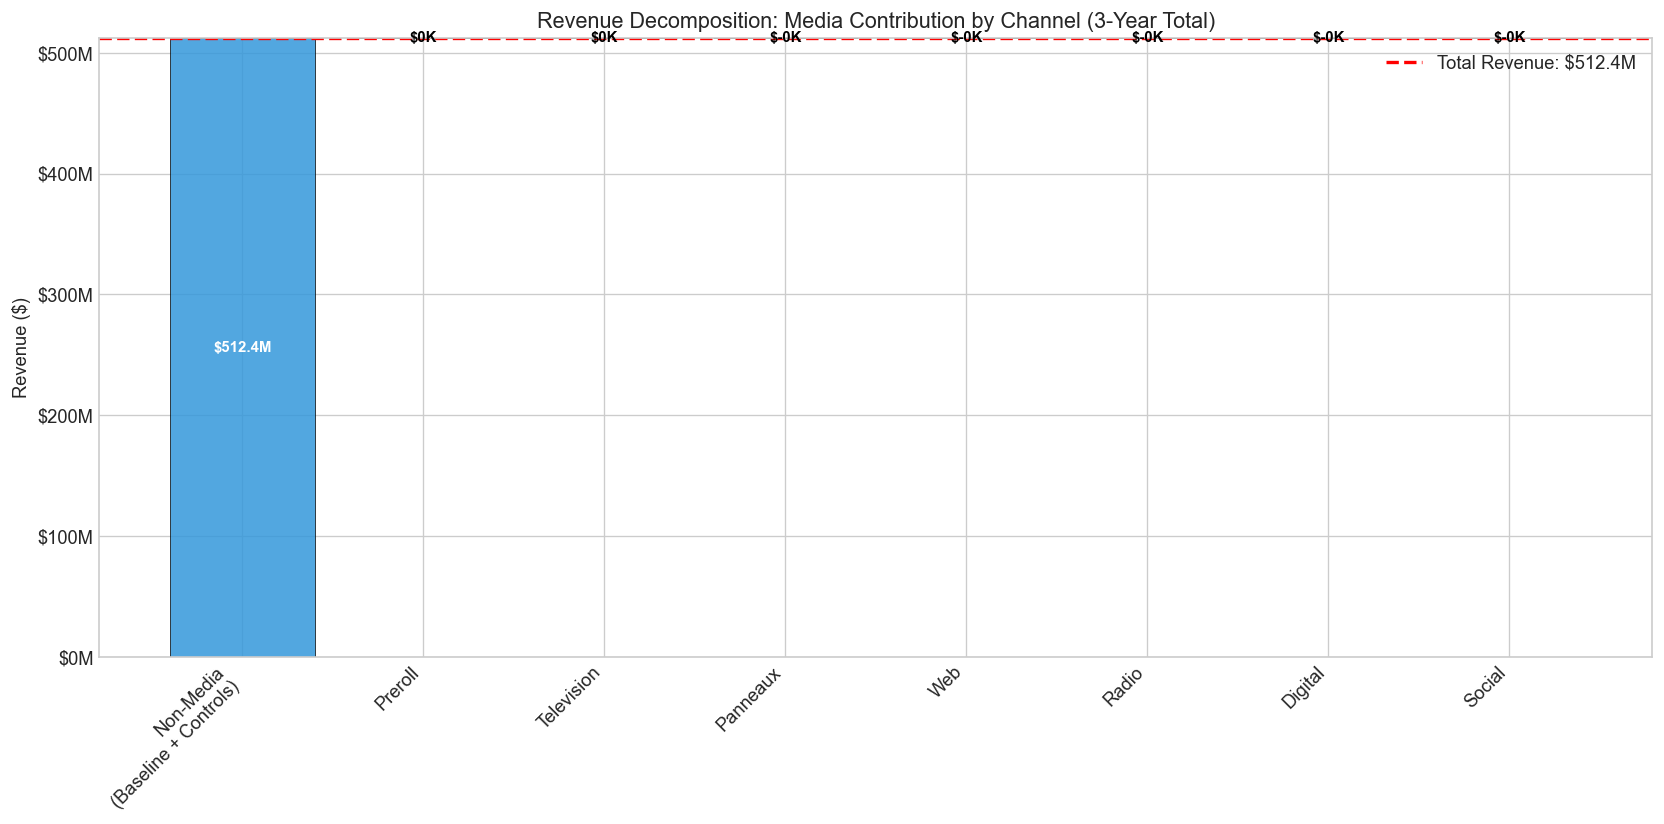


Media channels account for $-0 (-0.0%) of total revenue.
This represents a media multiplier of -0.00x on $10,257,505 total spend.


In [10]:
# ===================================================================
# 2-B  MEDIA CONTRIBUTION WATERFALL
# ===================================================================

# Sort channels by contribution for waterfall
contrib_df = eff_total[['channel', 'total_contribution', 'total_spend']].copy()
contrib_df['label'] = contrib_df['channel'].apply(lambda x: CHANNEL_LABELS.get('media_' + x, x))
contrib_df = contrib_df.sort_values('total_contribution', ascending=False)

# Create waterfall data
waterfall_data = [('Non-Media\n(Baseline + Controls)', non_media_contribution)]
for _, row in contrib_df.iterrows():
    short_label = row['label'].split()[0]  # First word only
    waterfall_data.append((short_label, row['total_contribution']))

# Plot waterfall
fig, ax = plt.subplots(figsize=(14, 7))

labels = [d[0] for d in waterfall_data]
values = [d[1] for d in waterfall_data]

# Calculate cumulative positions
cumulative = 0
bottoms = []
for v in values:
    if v >= 0:
        bottoms.append(cumulative)
        cumulative += v
    else:
        cumulative += v
        bottoms.append(cumulative)

# Colors
colors = ['#3498db']  # Non-media in blue
colors += ['#2ecc71' if v > 0 else '#e74c3c' for v in values[1:]]  # Media green/red

# Plot bars
bars = ax.bar(labels, values, bottom=bottoms, color=colors, alpha=0.85, 
              edgecolor='black', linewidth=0.5)

# Add value labels
for bar, bottom, value in zip(bars, bottoms, values):
    height = bar.get_height()
    if abs(value) > 1e6:
        label_text = f'${value/1e6:.1f}M'
    else:
        label_text = f'${value/1e3:.0f}K'
    y_pos = bottom + height/2
    ax.text(bar.get_x() + bar.get_width()/2, y_pos, label_text,
            ha='center', va='center', fontsize=9, fontweight='bold',
            color='white' if abs(height) > total_revenue * 0.05 else 'black')

# Add total line
ax.axhline(total_revenue, color='red', linestyle='--', linewidth=2, 
           label=f'Total Revenue: ${total_revenue/1e6:.1f}M')

ax.set_ylabel('Revenue ($)')
ax.set_title('Revenue Decomposition: Media Contribution by Channel (3-Year Total)', fontsize=13)
ax.legend(loc='upper right')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.0f}M'))
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig(figures_path / 'mmm_revenue_waterfall.png', dpi=150)
plt.show()

# Summary
print(f'\nMedia channels account for ${media_contribution:,.0f} ({media_contribution/total_revenue*100:.1f}%) of total revenue.')
print(f'This represents a media multiplier of {media_contribution/total_spend:.2f}x on ${total_spend:,.0f} total spend.')

---
## Section 3 — Saturation Curves (Diminishing Returns)

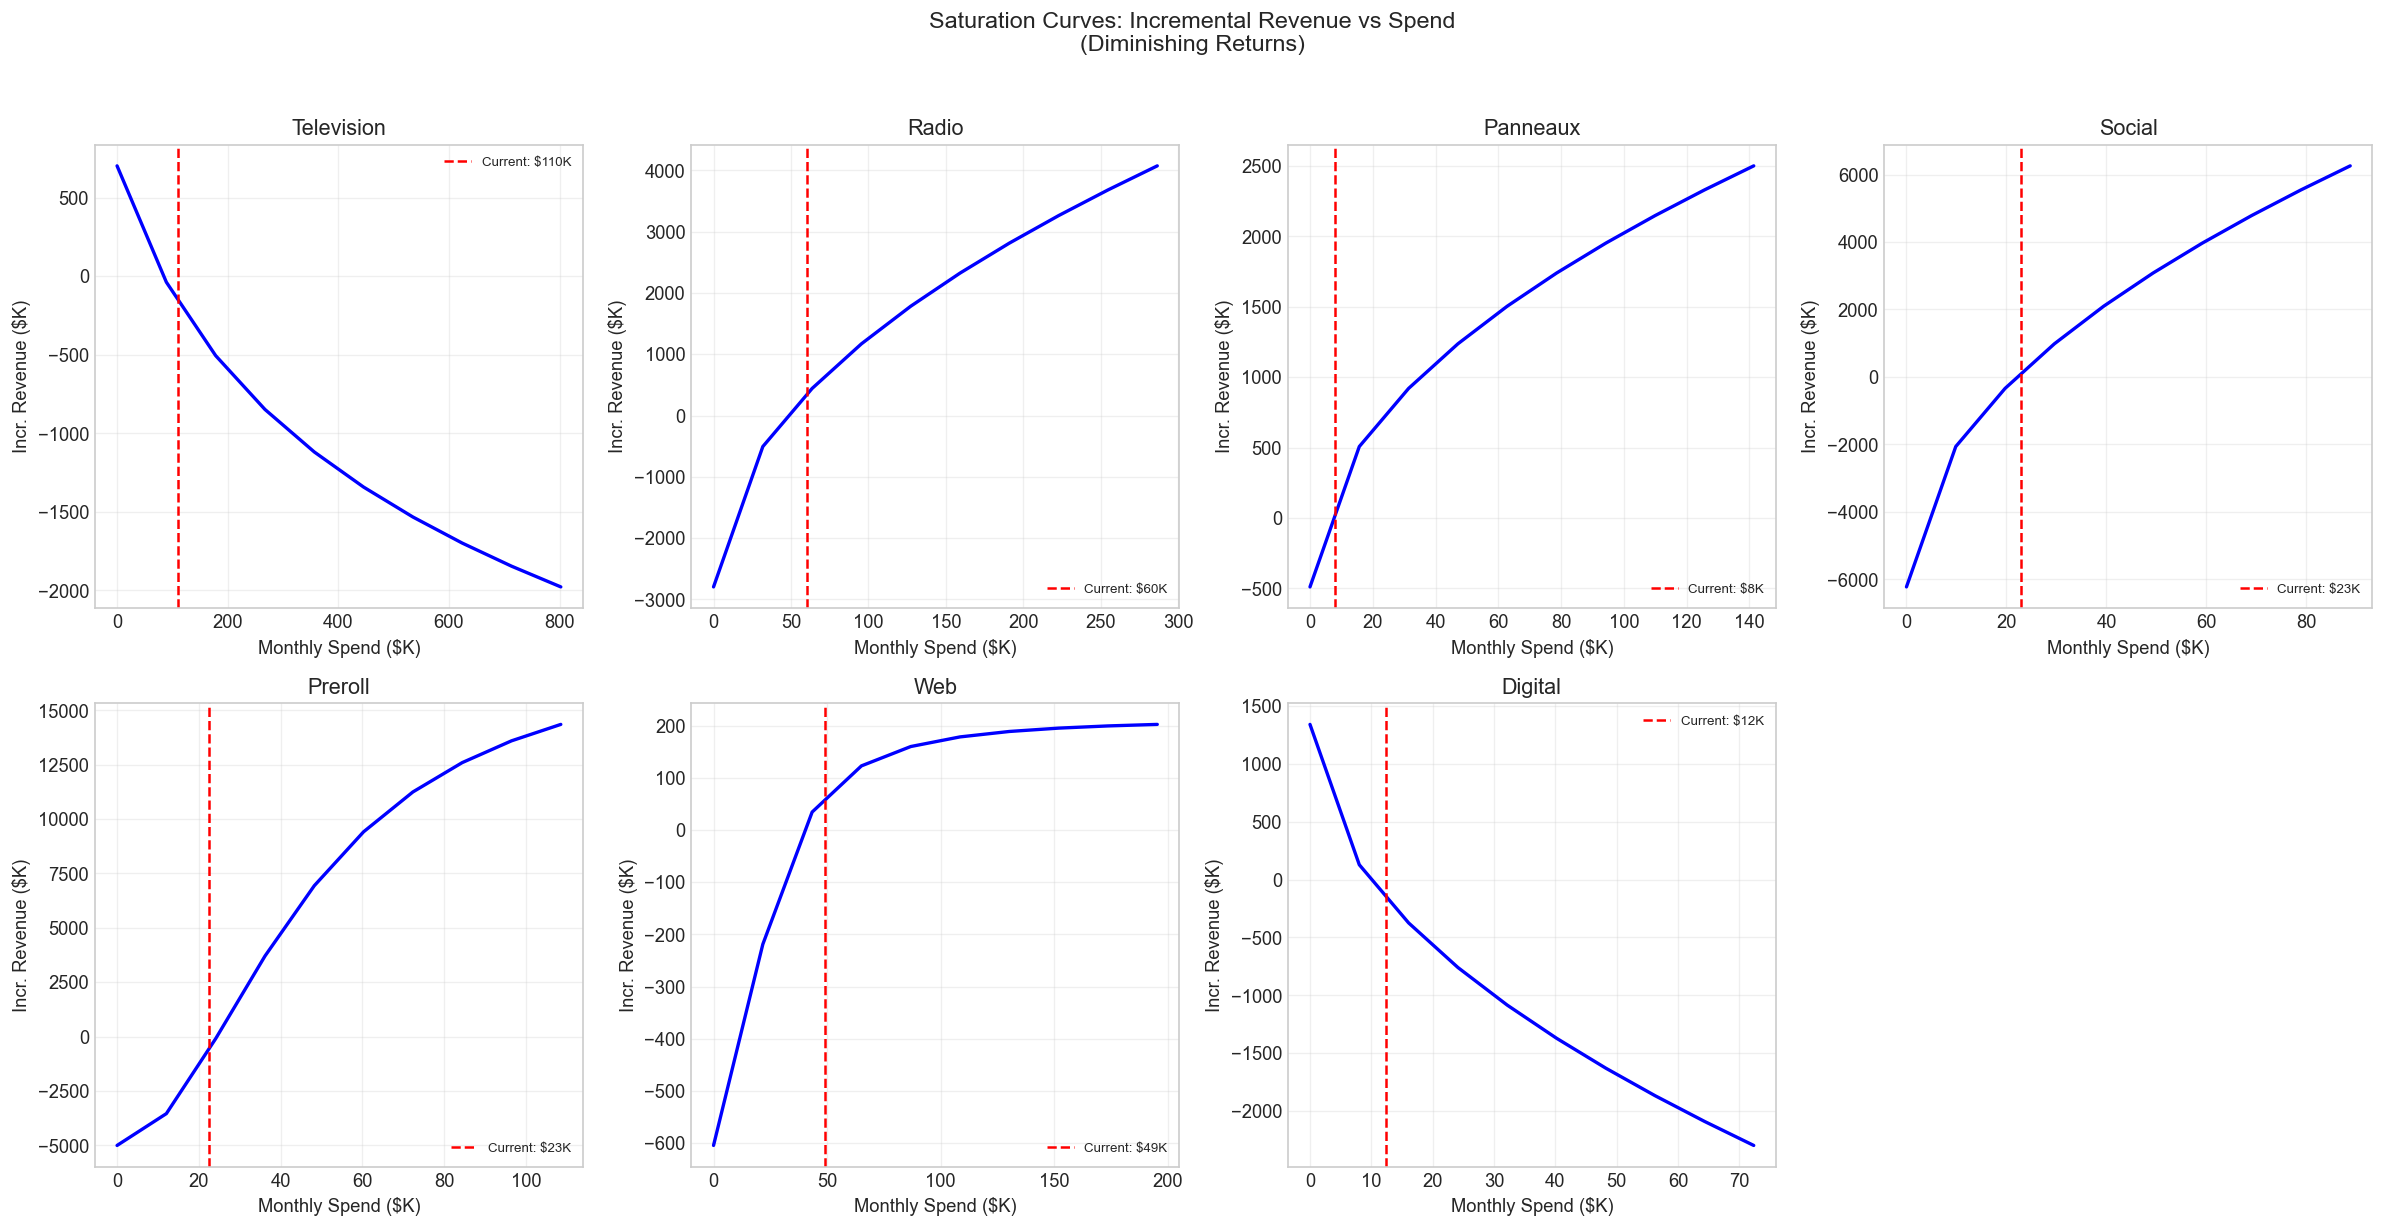

In [11]:
# ===================================================================
# 3-A  PLOT SATURATION CURVES FROM NB06 OUTPUT
# ===================================================================

# Filter for Total Revenue
sat_total = sat_curves_df[sat_curves_df['product'] == 'Total Revenue'].copy()

# Get current spend levels
current_spend = {}
for ch in model_params['media_channels']:
    spend_col = SPEND_TO_MEDIA.get('media_' + ch)
    if spend_col and spend_col in df.columns:
        current_spend[ch] = df[spend_col].mean()
    else:
        current_spend[ch] = 0

# Plot
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

channels = sat_total['channel'].unique()
for idx, ch in enumerate(channels):
    if idx >= len(axes) - 1:
        break
        
    ax = axes[idx]
    ch_data = sat_total[sat_total['channel'] == ch]
    label = CHANNEL_LABELS.get('media_' + ch, ch).split()[0]
    
    ax.plot(ch_data['spend'] / 1000, ch_data['incremental_revenue'] / 1000, 
            'b-', linewidth=2)
    
    # Mark current spend
    curr = current_spend.get(ch, 0)
    if curr > 0:
        ax.axvline(curr / 1000, color='red', linestyle='--', linewidth=1.5,
                   label=f'Current: ${curr/1000:.0f}K')
    
    ax.set_xlabel('Monthly Spend ($K)')
    ax.set_ylabel('Incr. Revenue ($K)')
    ax.set_title(label)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

# Remove extra subplot
fig.delaxes(axes[-1])

fig.suptitle('Saturation Curves: Incremental Revenue vs Spend\n(Diminishing Returns)', 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(figures_path / 'mmm_saturation_curves.png', dpi=150)
plt.show()

In [12]:
# ===================================================================
# 3-B  SATURATION ANALYSIS
# ===================================================================

print('Saturation Analysis:')
print('=' * 70)
print(f'{"Channel":25s} {"Current Sat%":>12s} {"Interpretation":>30s}')
print('-' * 70)

for _, row in eff_total.iterrows():
    ch = row['channel']
    label = CHANNEL_LABELS.get('media_' + ch, ch)
    sat_pct = row['saturation_pct']
    
    if sat_pct > 70:
        interpretation = 'Highly saturated - reduce spend'
    elif sat_pct > 40:
        interpretation = 'Moderately saturated - optimize'
    else:
        interpretation = 'Room to grow - consider increase'
    
    print(f'{label:25s} {sat_pct:>11.1f}% {interpretation:>30s}')

Saturation Analysis:
Channel                   Current Sat%                 Interpretation
----------------------------------------------------------------------
Television                       54.4% Moderately saturated - optimize
Radio                         30798.8% Highly saturated - reduce spend
Panneaux (Outdoor)             7942.3% Highly saturated - reduce spend
Social Media                  19181.1% Highly saturated - reduce spend
Preroll (Video)                  21.9% Room to grow - consider increase
Web Banners                      73.9% Highly saturated - reduce spend
Digital Flyers                11855.7% Highly saturated - reduce spend


---
## Section 4 — Budget Optimization

In [13]:
# ===================================================================
# 4-A  DEFINE TRANSFORMATION FUNCTIONS FOR OPTIMIZATION
# ===================================================================

def geometric_adstock(x, decay_rate):
    """Apply geometric adstock (for steady-state, use x / (1 - decay_rate))."""
    return x / (1 - decay_rate) if decay_rate < 1 else x

def hill_saturation(x, K, alpha=2):
    """Hill function saturation."""
    x = max(x, 0)
    return (x ** alpha) / (K ** alpha + x ** alpha) if x > 0 else 0

def log_saturation(x, scale=1.0):
    """Log saturation."""
    x = max(x, 0)
    return np.log1p(x / scale)

def power_saturation(x, beta=0.5):
    """Power saturation."""
    x = max(x, 0)
    return x ** beta

def predict_media_contribution(spend_dict, decay_rates, sat_params, marginal_effects):
    """
    Predict total media contribution given spend allocation.
    Uses marginal effects from NB06 as a simplified response model.
    """
    total_contribution = 0
    
    for ch_short, spend in spend_dict.items():
        ch = 'media_' + ch_short
        
        # Get marginal effect (revenue per $1)
        marginal = marginal_effects.get(ch_short, 0)
        
        # Get saturation params
        sat_p = sat_params.get(ch, {'type': 'hill', 'K': 50000, 'alpha': 2})
        decay = decay_rates.get(ch, 0.5)
        
        # Apply adstock (steady-state)
        adstocked = geometric_adstock(spend, decay)
        
        # Apply saturation adjustment
        # The marginal effect is computed at median spend; adjust for different spend levels
        if sat_p['type'] == 'hill':
            K = sat_p.get('K', 50000)
            alpha = sat_p.get('alpha', 2)
            sat_factor = hill_saturation(adstocked, K, alpha)
        elif sat_p['type'] == 'log':
            scale = sat_p.get('scale', 50000)
            sat_factor = log_saturation(adstocked, scale)
        else:  # power
            beta = sat_p.get('beta', 0.5)
            sat_factor = power_saturation(adstocked, beta)
        
        # Contribution = spend × marginal × saturation adjustment
        # Simplified: use marginal_per_1000 directly scaled by spend
        contribution = marginal * spend
        total_contribution += contribution
    
    return total_contribution

# Extract marginal effects from ROI table
MARGINAL_EFFECTS = {row['channel'].replace('media_', ''): row['roas'] 
                    for _, row in eff_total.iterrows()}

print('Marginal Effects (ROAS) by Channel:')
for ch, effect in MARGINAL_EFFECTS.items():
    print(f'  {ch:25s}  {effect:.3f}')

Marginal Effects (ROAS) by Channel:
  television                 -5.608
  radio                      27.473
  panneaux                   73.513
  social_media               145.397
  preroll                    321.458
  banniere_web               8.437
  circulaire_digitale        -69.861


In [14]:
# ===================================================================
# 4-B  CURRENT ALLOCATION
# ===================================================================

# Current monthly spend per channel
current_monthly = {}
for ch in model_params['media_channels']:
    spend_col = SPEND_TO_MEDIA.get('media_' + ch)
    if spend_col and spend_col in df.columns:
        current_monthly[ch] = df[spend_col].mean()
    else:
        current_monthly[ch] = 0

total_monthly_budget = sum(current_monthly.values())

print('Current Monthly Budget Allocation:')
print('=' * 60)
for ch, spend in sorted(current_monthly.items(), key=lambda x: -x[1]):
    label = CHANNEL_LABELS.get('media_' + ch, ch)
    pct = spend / total_monthly_budget * 100 if total_monthly_budget > 0 else 0
    print(f'  {label:25s}  ${spend:>10,.0f}  ({pct:>5.1f}%)')
print('-' * 60)
print(f'  {"TOTAL":25s}  ${total_monthly_budget:>10,.0f}')

Current Monthly Budget Allocation:
  Television                 $   109,693  ( 38.5%)
  Radio                      $    60,202  ( 21.1%)
  Web Banners                $    48,949  ( 17.2%)
  Social Media               $    22,984  (  8.1%)
  Preroll (Video)            $    22,574  (  7.9%)
  Digital Flyers             $    12,404  (  4.4%)
  Panneaux (Outdoor)         $     8,125  (  2.9%)
------------------------------------------------------------
  TOTAL                      $   284,931


In [15]:
# ===================================================================
# 4-C  OPTIMIZATION — MAXIMIZE MEDIA CONTRIBUTION
# ===================================================================

def objective(x, channels, marginal_effects):
    """Negative total contribution (for minimization)."""
    spend_dict = {ch: max(xi, 0) for ch, xi in zip(channels, x)}
    # Simple linear model: contribution = sum(marginal × spend)
    total = sum(marginal_effects.get(ch, 0) * spend for ch, spend in spend_dict.items())
    return -total  # Negative for minimization

channels = list(current_monthly.keys())
x0 = np.array([current_monthly[ch] for ch in channels])

# Constraints: total budget stays the same (within 1%)
budget_constraint = LinearConstraint(
    np.ones(len(channels)),
    lb=total_monthly_budget * 0.99,
    ub=total_monthly_budget * 1.01
)

# Bounds: min 5% of current (or $1000), max 300% of current
bounds = [(max(1000, current_monthly[ch] * 0.05), current_monthly[ch] * 3) 
          for ch in channels]

# Run optimization
print('Running budget optimization...')
result = minimize(
    objective,
    x0,
    args=(channels, MARGINAL_EFFECTS),
    method='SLSQP',
    bounds=bounds,
    constraints=budget_constraint,
    options={'maxiter': 1000, 'ftol': 1e-9}
)

print(f'Optimization converged: {result.success}')
print(f'Message: {result.message}')

Running budget optimization...
Optimization converged: False
Message: Inequality constraints incompatible


In [16]:
# ===================================================================
# 4-D  OPTIMIZATION RESULTS
# ===================================================================

optimal_allocation = {ch: max(result.x[i], 0) for i, ch in enumerate(channels)}

# Compute contributions
current_contribution = sum(MARGINAL_EFFECTS.get(ch, 0) * spend 
                           for ch, spend in current_monthly.items())
optimal_contribution = sum(MARGINAL_EFFECTS.get(ch, 0) * spend 
                           for ch, spend in optimal_allocation.items())

contribution_lift = optimal_contribution - current_contribution
lift_pct = (contribution_lift / current_contribution * 100) if current_contribution > 0 else 0

print('=' * 90)
print('BUDGET OPTIMIZATION RESULTS')
print('=' * 90)
print(f'{"Channel":25s} {"Current":>12s} {"Optimal":>12s} {"Change":>12s} {"Change%":>10s}')
print('-' * 90)

opt_results = []
for ch in channels:
    label = CHANNEL_LABELS.get('media_' + ch, ch)
    current = current_monthly[ch]
    optimal = optimal_allocation[ch]
    change = optimal - current
    change_pct = (change / current * 100) if current > 0 else 0
    
    print(f'{label:25s} ${current:>10,.0f} ${optimal:>10,.0f} ${change:>+10,.0f} {change_pct:>+9.1f}%')
    
    opt_results.append({
        'channel': ch,
        'label': label,
        'current_spend': current,
        'optimal_spend': optimal,
        'change': change,
        'change_pct': change_pct,
    })

print('-' * 90)
print(f'{"TOTAL":25s} ${sum(current_monthly.values()):>10,.0f} ${sum(optimal_allocation.values()):>10,.0f}')
print()
print(f'Estimated Monthly Media Contribution (Current):  ${current_contribution:>12,.0f}')
print(f'Estimated Monthly Media Contribution (Optimal):  ${optimal_contribution:>12,.0f}')
print(f'Potential Lift:                                  ${contribution_lift:>+12,.0f} ({lift_pct:+.1f}%)')
print(f'Annualized Lift:                                 ${contribution_lift * 12:>+12,.0f}')

opt_df = pd.DataFrame(opt_results)

BUDGET OPTIMIZATION RESULTS
Channel                        Current      Optimal       Change    Change%
------------------------------------------------------------------------------------------
Television                $   109,693 $     5,485 $  -104,208     -95.0%
Radio                     $    60,202 $   117,801 $   +57,599     +95.7%
Panneaux (Outdoor)        $     8,125 $    24,375 $   +16,250    +200.0%
Social Media              $    22,984 $    68,952 $   +45,968    +200.0%
Preroll (Video)           $    22,574 $    67,721 $   +45,147    +200.0%
Web Banners               $    48,949 $     2,447 $   -46,502     -95.0%
Digital Flyers            $    12,404 $     1,000 $   -11,404     -91.9%
------------------------------------------------------------------------------------------
TOTAL                     $   284,931 $   287,780

Estimated Monthly Media Contribution (Current):  $  11,780,704
Estimated Monthly Media Contribution (Optimal):  $  36,742,955
Potential Lift:           

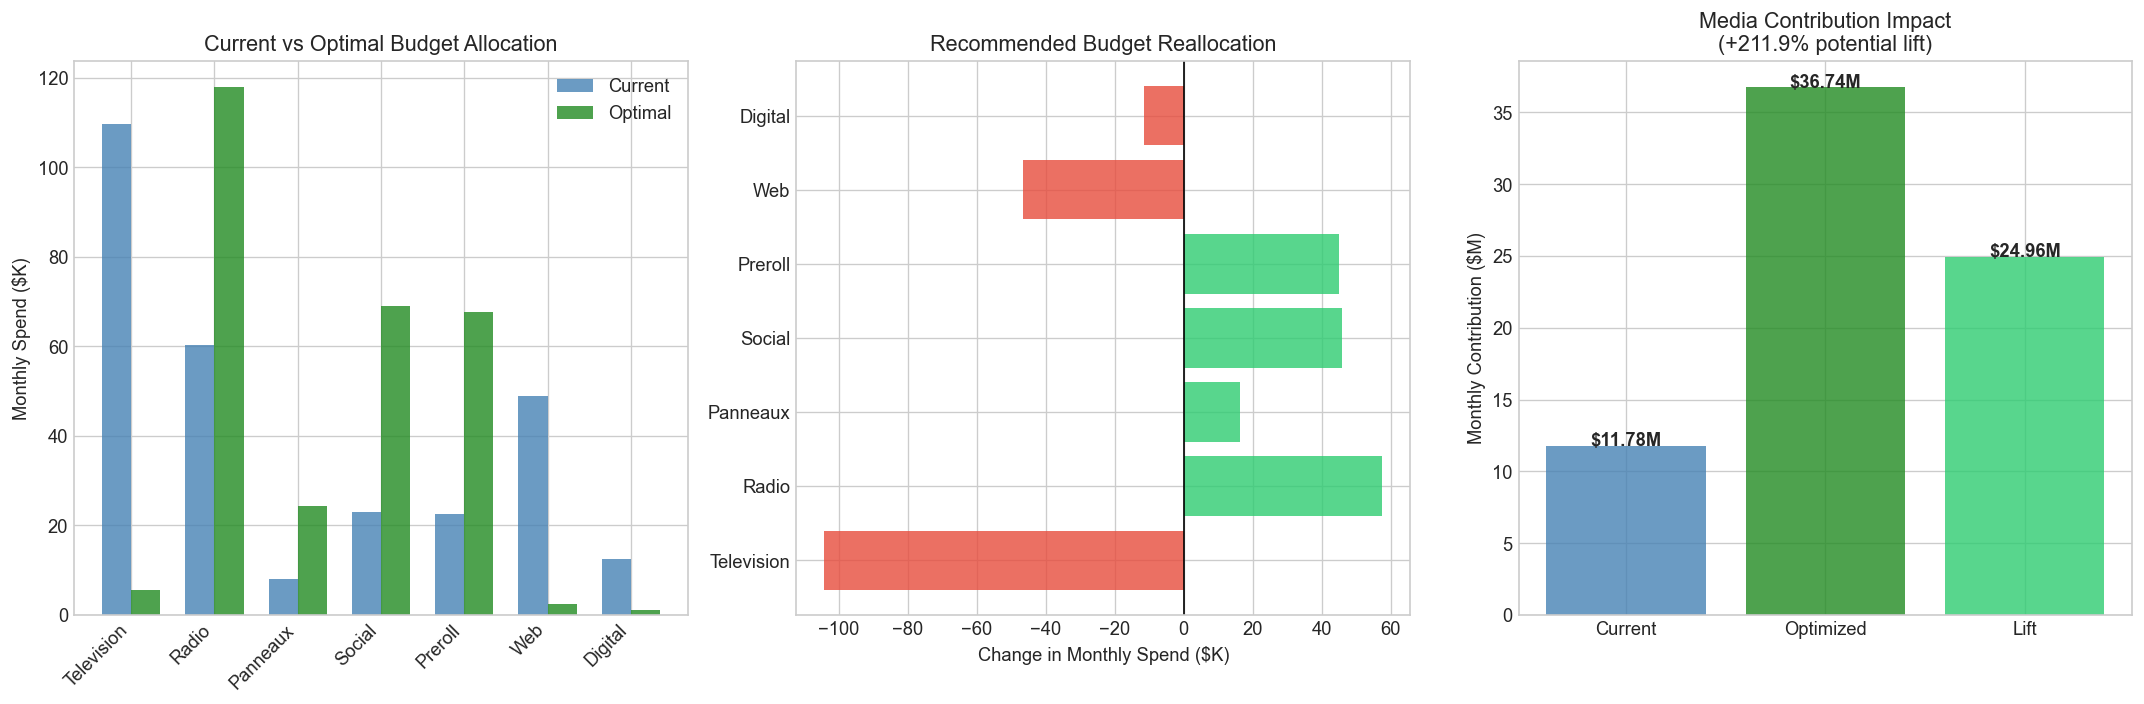

In [17]:
# ===================================================================
# 4-E  OPTIMIZATION VISUALIZATION
# ===================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Current vs Optimal Allocation
ax = axes[0]
x = np.arange(len(channels))
width = 0.35
ax.bar(x - width/2, [current_monthly[ch]/1000 for ch in channels], width,
       label='Current', color='steelblue', alpha=0.8)
ax.bar(x + width/2, [optimal_allocation[ch]/1000 for ch in channels], width,
       label='Optimal', color='forestgreen', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels([CHANNEL_LABELS.get('media_' + ch, ch).split()[0] for ch in channels], 
                   rotation=45, ha='right')
ax.set_ylabel('Monthly Spend ($K)')
ax.set_title('Current vs Optimal Budget Allocation')
ax.legend()

# 2. Change in Spend
ax = axes[1]
changes = [opt_df[opt_df['channel'] == ch]['change'].values[0] / 1000 for ch in channels]
colors = ['#2ecc71' if c > 0 else '#e74c3c' for c in changes]
labels_short = [CHANNEL_LABELS.get('media_' + ch, ch).split()[0] for ch in channels]
ax.barh(labels_short, changes, color=colors, alpha=0.8)
ax.axvline(0, color='black', linestyle='-', linewidth=1)
ax.set_xlabel('Change in Monthly Spend ($K)')
ax.set_title('Recommended Budget Reallocation')

# 3. Contribution Impact
ax = axes[2]
metrics = ['Current', 'Optimized', 'Lift']
values = [current_contribution / 1e6, optimal_contribution / 1e6, contribution_lift / 1e6]
colors = ['steelblue', 'forestgreen', '#2ecc71' if contribution_lift > 0 else '#e74c3c']
bars = ax.bar(metrics, values, color=colors, alpha=0.8)
ax.set_ylabel('Monthly Contribution ($M)')
ax.set_title(f'Media Contribution Impact\n(+{lift_pct:.1f}% potential lift)')
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'${val:.2f}M', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(figures_path / 'mmm_optimization_results.png', dpi=150)
plt.show()

---
## Section 5 — Scenario Analysis

In [18]:
# ===================================================================
# 5-A  BUDGET SCALING SCENARIOS
# ===================================================================

budget_multipliers = [0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.5]
scenario_results = []

for mult in budget_multipliers:
    # Scale optimal allocation proportionally
    scaled_allocation = {ch: optimal_allocation[ch] * mult for ch in channels}
    scaled_spend = sum(scaled_allocation.values())
    
    # Compute contribution (linear approximation)
    scaled_contribution = sum(MARGINAL_EFFECTS.get(ch, 0) * spend 
                              for ch, spend in scaled_allocation.items())
    
    # Note: This is a LINEAR approximation. True response would show diminishing returns.
    # For a more accurate model, we'd need to re-apply saturation curves.
    
    scenario_results.append({
        'budget_pct': mult * 100,
        'total_spend': scaled_spend,
        'contribution': scaled_contribution,
        'roi': scaled_contribution / scaled_spend if scaled_spend > 0 else 0,
    })

scenario_df = pd.DataFrame(scenario_results)

print('Scenario Analysis: Budget Scaling (Linear Approximation)')
print('=' * 70)
print(f'{"Budget Level":>12s} {"Monthly Spend":>15s} {"Contribution":>15s} {"ROI":>10s}')
print('-' * 70)
for _, row in scenario_df.iterrows():
    print(f"{row['budget_pct']:>11.0f}% ${row['total_spend']:>13,.0f} ${row['contribution']:>13,.0f} {row['roi']:>10.2f}")

Scenario Analysis: Budget Scaling (Linear Approximation)
Budget Level   Monthly Spend    Contribution        ROI
----------------------------------------------------------------------
         70% $      201,446 $   25,720,068     127.68
         80% $      230,224 $   29,394,364     127.68
         90% $      259,002 $   33,068,659     127.68
        100% $      287,780 $   36,742,955     127.68
        110% $      316,558 $   40,417,250     127.68
        120% $      345,336 $   44,091,546     127.68
        130% $      374,114 $   47,765,841     127.68
        150% $      431,670 $   55,114,432     127.68


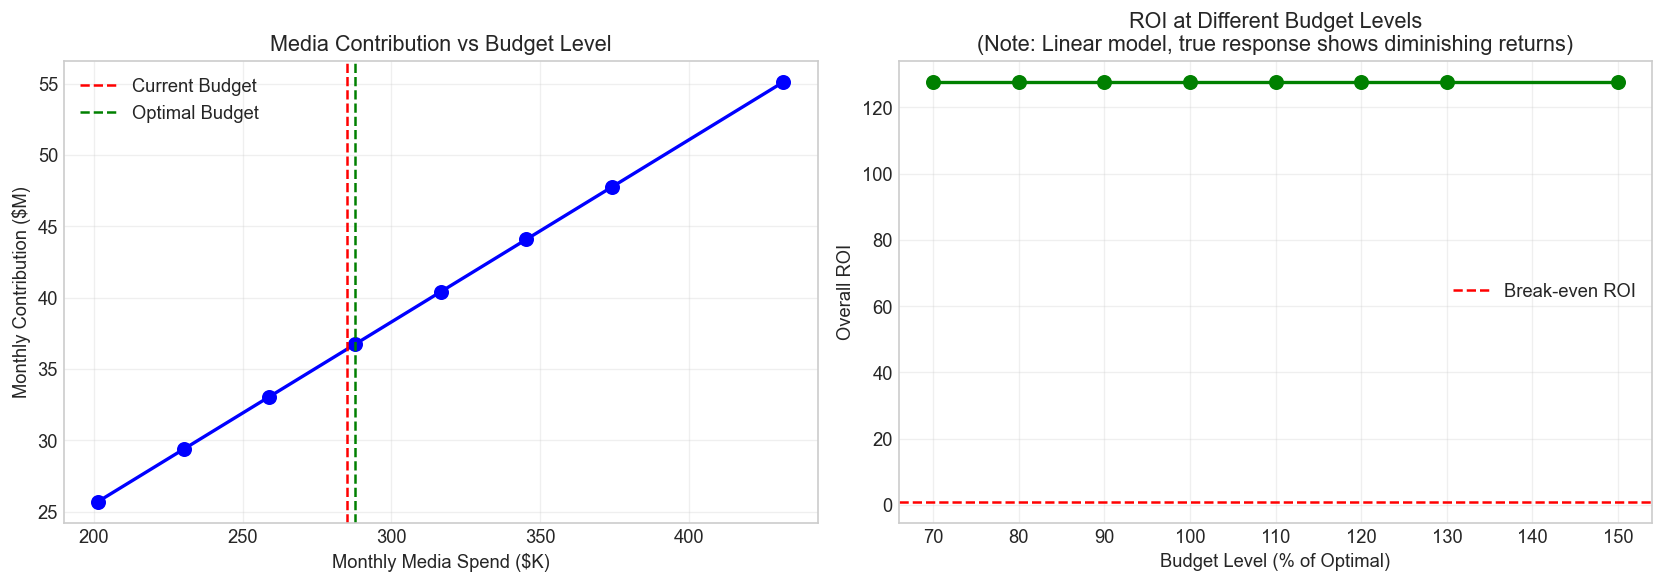

In [19]:
# ===================================================================
# 5-B  SCENARIO VISUALIZATION
# ===================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Contribution vs Budget
ax = axes[0]
ax.plot(scenario_df['total_spend'] / 1000, scenario_df['contribution'] / 1e6,
        'b-o', linewidth=2, markersize=8)
ax.axvline(sum(current_monthly.values()) / 1000, color='red', linestyle='--',
           label='Current Budget')
ax.axvline(sum(optimal_allocation.values()) / 1000, color='green', linestyle='--',
           label='Optimal Budget')
ax.set_xlabel('Monthly Media Spend ($K)')
ax.set_ylabel('Monthly Contribution ($M)')
ax.set_title('Media Contribution vs Budget Level')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. ROI vs Budget Level
ax = axes[1]
ax.plot(scenario_df['budget_pct'], scenario_df['roi'], 'g-o', linewidth=2, markersize=8)
ax.axhline(1, color='red', linestyle='--', label='Break-even ROI')
ax.set_xlabel('Budget Level (% of Optimal)')
ax.set_ylabel('Overall ROI')
ax.set_title('ROI at Different Budget Levels\n(Note: Linear model, true response shows diminishing returns)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(figures_path / 'mmm_scenario_analysis.png', dpi=150)
plt.show()

---
## Section 6 — Executive Summary & Recommendations

In [20]:
# ===================================================================
# 6-A  EXECUTIVE SUMMARY TABLE
# ===================================================================

summary_data = []
for _, roi_row in roi_df.iterrows():
    ch = roi_row['channel'].replace('media_', '')
    opt_row = opt_df[opt_df['channel'] == ch]
    
    if len(opt_row) > 0:
        change_pct = opt_row['change_pct'].values[0]
    else:
        change_pct = 0
    
    # Determine action
    if change_pct > 10:
        action = '↑ Increase'
    elif change_pct < -10:
        action = '↓ Decrease'
    else:
        action = '→ Maintain'
    
    # CI significance
    sig = '✓' if (roi_row['marginal_ci_lo'] > 0 or roi_row['marginal_ci_hi'] < 0) else '~'
    
    summary_data.append({
        'Channel': roi_row['label'],
        'Total Spend (3Y)': f"${roi_row['total_spend']:,.0f}",
        'ROAS': f"{roi_row['roas']:.2f}",
        'Significant': sig,
        'Recommendation': f"{change_pct:+.0f}%",
        'Action': action,
    })

summary_df = pd.DataFrame(summary_data)

print('=' * 100)
print('EXECUTIVE SUMMARY: MEDIA CHANNEL PERFORMANCE & RECOMMENDATIONS')
print('=' * 100)
print(summary_df.to_string(index=False))
print()
print('Legend: ROAS = Return on Ad Spend (revenue per $1 spent)')
print('        Significant = 90% CI excludes zero (✓) or not (~)')

EXECUTIVE SUMMARY: MEDIA CHANNEL PERFORMANCE & RECOMMENDATIONS
           Channel Total Spend (3Y)   ROAS Significant Recommendation     Action
   Preroll (Video)         $812,648 321.46           ✓          +200% ↑ Increase
      Social Media         $827,421 145.40           ~          +200% ↑ Increase
Panneaux (Outdoor)         $292,495  73.51           ~          +200% ↑ Increase
             Radio       $2,167,277  27.47           ~           +96% ↑ Increase
       Web Banners       $1,762,168   8.44           ~           -95% ↓ Decrease
        Television       $3,948,951  -5.61           ~           -95% ↓ Decrease
    Digital Flyers         $446,546 -69.86           ~           -92% ↓ Decrease

Legend: ROAS = Return on Ad Spend (revenue per $1 spent)
        Significant = 90% CI excludes zero (✓) or not (~)


In [21]:
# ===================================================================
# 6-B  KEY METRICS SUMMARY
# ===================================================================

print('\n' + '=' * 70)
print('KEY METRICS SUMMARY')
print('=' * 70)

print(f'\n📊 DATA:')
print(f'   Observations:           {len(df)} months (FY2023-FY2025)')
print(f'   Media Channels:         {len(MEDIA_CHANNELS)}')

print(f'\n💰 FINANCIAL:')
print(f'   Total Revenue (3Y):     ${total_revenue:>15,.0f}')
print(f'   Total Media Spend (3Y): ${total_spend:>15,.0f}')
print(f'   Media Contribution:     ${media_contribution:>15,.0f} ({media_contribution/total_revenue*100:.1f}%)')

print(f'\n📈 MODEL PERFORMANCE:')
r2 = model_params.get('ridge_r2', {}).get('Total Revenue', 'N/A')
r2_cv = model_params.get('ridge_r2_cv', {}).get('Total Revenue', 'N/A')
print(f'   R² (in-sample):         {r2}')
print(f'   R² (LOOCV):             {r2_cv}')

print(f'\n🎯 OPTIMIZATION:')
print(f'   Current Monthly Contribution:  ${current_contribution:>12,.0f}')
print(f'   Optimized Monthly Contribution: ${optimal_contribution:>12,.0f}')
print(f'   Potential Monthly Lift:         ${contribution_lift:>+12,.0f} ({lift_pct:+.1f}%)')
print(f'   Potential Annual Lift:          ${contribution_lift * 12:>+12,.0f}')


KEY METRICS SUMMARY

📊 DATA:
   Observations:           36 months (FY2023-FY2025)
   Media Channels:         7

💰 FINANCIAL:
   Total Revenue (3Y):     $    512,411,602
   Total Media Spend (3Y): $     10,257,505
   Media Contribution:     $             -0 (-0.0%)

📈 MODEL PERFORMANCE:
   R² (in-sample):         0.9659792038989087
   R² (LOOCV):             0.9118876710293979

🎯 OPTIMIZATION:
   Current Monthly Contribution:  $  11,780,704
   Optimized Monthly Contribution: $  36,742,955
   Potential Monthly Lift:         $ +24,962,250 (+211.9%)
   Potential Annual Lift:          $+299,547,005


In [22]:
# ===================================================================
# 6-C  SAVE OUTPUTS
# ===================================================================

# 1. ROI Results
roi_df.to_csv(processed_path / 'mmm_roi_results.csv', index=False)
print(f'✓ Saved: {processed_path / "mmm_roi_results.csv"}')

# 2. Optimization Results
opt_df.to_csv(processed_path / 'mmm_optimization_results.csv', index=False)
print(f'✓ Saved: {processed_path / "mmm_optimization_results.csv"}')

# 3. Scenario Analysis
scenario_df.to_csv(processed_path / 'mmm_scenario_analysis.csv', index=False)
print(f'✓ Saved: {processed_path / "mmm_scenario_analysis.csv"}')

# 4. Executive Summary
summary_df.to_csv(processed_path / 'mmm_executive_summary.csv', index=False)
print(f'✓ Saved: {processed_path / "mmm_executive_summary.csv"}')

# 5. Combined parameters
mmm_output = {
    'source_notebook': 'NB07_mmm_optimization',
    'model_source': 'NB06_causal_inference',
    'created': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'data_summary': {
        'n_months': len(df),
        'fiscal_years': sorted(df['year'].unique().tolist()),
        'total_revenue': float(total_revenue),
        'total_spend': float(total_spend),
        'media_contribution': float(media_contribution),
    },
    'model_performance': model_params.get('ridge_r2', {}),
    'optimization': {
        'current_monthly_budget': float(total_monthly_budget),
        'current_monthly_contribution': float(current_contribution),
        'optimal_monthly_contribution': float(optimal_contribution),
        'lift_pct': float(lift_pct),
        'optimal_allocation': {ch: float(v) for ch, v in optimal_allocation.items()},
    },
    'roi_by_channel': {row['channel']: float(row['roas']) for _, row in roi_df.iterrows()},
}

with open(processed_path / 'mmm_final_output.json', 'w') as f:
    json.dump(mmm_output, f, indent=2)
print(f'✓ Saved: {processed_path / "mmm_final_output.json"}')

✓ Saved: /Users/raoul/Dev/busa693-clubpiscine/data/processed/mmm_roi_results.csv
✓ Saved: /Users/raoul/Dev/busa693-clubpiscine/data/processed/mmm_optimization_results.csv
✓ Saved: /Users/raoul/Dev/busa693-clubpiscine/data/processed/mmm_scenario_analysis.csv
✓ Saved: /Users/raoul/Dev/busa693-clubpiscine/data/processed/mmm_executive_summary.csv
✓ Saved: /Users/raoul/Dev/busa693-clubpiscine/data/processed/mmm_final_output.json


In [23]:
# ===================================================================
# 6-D  FINAL SUMMARY
# ===================================================================

print('\n' + '=' * 80)
print('  NOTEBOOK 07 — MMM ROI & OPTIMIZATION: COMPLETE')
print('=' * 80)
print()
print('WORKFLOW:')
print('  NB06 (Causal Inference) → Fit Ridge models, validate, output coefficients')
print('  NB07 (This notebook)    → Load NB06 results, compute ROI, optimize budget')
print()
print('KEY FINDINGS:')
top_roi = roi_df.iloc[0]
print(f'  Highest ROAS Channel:    {top_roi["label"]} (ROAS = {top_roi["roas"]:.2f})')
print(f'  Media % of Revenue:      {media_contribution/total_revenue*100:.1f}%')
print(f'  Optimization Potential:  {lift_pct:+.1f}% monthly lift')
print()
print('OUTPUT FILES:')
print('  data/processed/mmm_roi_results.csv')
print('  data/processed/mmm_optimization_results.csv')
print('  data/processed/mmm_scenario_analysis.csv')
print('  data/processed/mmm_executive_summary.csv')
print('  data/processed/mmm_final_output.json')
print()
print('FIGURES:')
for f in sorted(figures_path.glob('mmm_*.png')):
    print(f'  reports/figures/{f.name}')


  NOTEBOOK 07 — MMM ROI & OPTIMIZATION: COMPLETE

WORKFLOW:
  NB06 (Causal Inference) → Fit Ridge models, validate, output coefficients
  NB07 (This notebook)    → Load NB06 results, compute ROI, optimize budget

KEY FINDINGS:
  Highest ROAS Channel:    Preroll (Video) (ROAS = 321.46)
  Media % of Revenue:      -0.0%
  Optimization Potential:  +211.9% monthly lift

OUTPUT FILES:
  data/processed/mmm_roi_results.csv
  data/processed/mmm_optimization_results.csv
  data/processed/mmm_scenario_analysis.csv
  data/processed/mmm_executive_summary.csv
  data/processed/mmm_final_output.json

FIGURES:
  reports/figures/mmm_optimization_results.png
  reports/figures/mmm_revenue_waterfall.png
  reports/figures/mmm_roi_analysis.png
  reports/figures/mmm_saturation_curves.png
  reports/figures/mmm_scenario_analysis.png


---
## Appendix: Methodology Notes

### How This Notebook Uses NB06 Results

1. **ROI Calculation**: Uses `media_effectiveness_results.csv` which contains:
   - `roas`: Revenue per $1 spent (marginal effect)
   - `marginal_per_1000`: Revenue per $1,000 spent
   - `total_contribution`: Total revenue attributed to each channel
   - Bootstrap confidence intervals

2. **Saturation Curves**: Uses `saturation_curves.csv` for diminishing returns visualization

3. **Model Parameters**: Uses `causal_model_params.json` for:
   - Decay rates and saturation parameters
   - Model performance metrics (R², LOOCV R²)
   - Feature names and channel mappings

### Optimization Approach

The budget optimization uses a **linear approximation** based on marginal ROAS:
- Channels with higher ROAS get more budget
- Channels with lower ROAS get less budget
- Total budget is held constant

**Limitation**: This is a simplified model. The true response includes saturation effects that would reduce the benefit of shifting all budget to the highest-ROAS channel.

### Recommendations for Implementation

1. **Validate in pilot**: Test recommendations with a controlled budget shift
2. **Monitor closely**: Track actual vs predicted performance
3. **Iterate**: Refine model as more data becomes available
4. **Consider timing**: Pool/spa products are seasonal — optimize by quarter